# Dependent Trajectory — Delayed-Choice Conditional Colouring

Runs the **`dependent_trajectory`** mode on the same input as
`classical_vs_quantum_colouring`: full-STFT, one quantum delay line per
frequency bin, but the per-bin readout is the **route-1 conditional (retrodicted)
Bloch trajectory**.

For each bin we run *N* trajectories and, at each frame *n*, sort them by the
**delayed probe outcome** `measurement_record[n+delay]`, then average the Bloch
vector inside each class:

> b_a(n) = E[(σx, σy, σz)(n) | probe outcome at n+delay = a]

amplitude ← (1−⟨σz⟩)/2, phase ← atan2(⟨σy⟩, ⟨σx⟩) of the **averaged** vector.

We render three versions — `uncond` (average over all outcomes), `cond0`,
`cond1` — and compare against the deterministic **full-STFT quantum colour**
(Mode II) and a **classical partial-correlation** (delay-line) phase. Operating
point is the sweep sweet spot: delay=3, gx=0.20, gz=0.5, basis=x.

In [1]:
import numpy as np, matplotlib.pyplot as plt, soundfile, os, sys, time
from IPython.display import Audio, display

from scipy.signal import spectrogram as scipy_spectrogram
from IPython.display import Audio, display
sys.path.insert(0, '/Users/xxxxx/Documents/Projects/SMS/sms-tools')
sys.path.insert(0, '.')
import quantum_audio_master as qam
from quantum_audio_master import (sms_analyse, synthesise_sms, merge_sms_to_stft,
    separate_sinusoidal_from_stft, normalize_amplitudes,
    _quantum_colour_transform_per_bin)
from dependent_trajectory import dependent_colour_transform_per_bin, adaptive_bandwidth_params
plt.rcParams['figure.figsize'] = (14, 4); plt.rcParams['figure.dpi'] = 100
print('Imports OK')

Imports OK


## 1. Parameters

In [2]:
AUDIO_PATH = 'audio/2807.wav'      # same input as classical_vs_quantum_colouring
TRIM_S = 10.0                  # seconds (window length)
START_S = 0.0                 # start offset into the file (seconds; was fixed at 0)
FADE_S = 0.2

# SMS analysis (reduced FFT so all-bins x trajectories stays tractable)
M, N_FFT, H = 2047, 2048, 512   # CONSTRAINT: sineModelSynth needs N_FFT <= 4*H
NH, MINF0   = 60, 100        # harmonic count + min f0 -> sms_analyse (nH auto-capped when ADAPTIVE_BANDWIDTH)
# Part I — residual INPUT to the delay line:
RESIDUAL_INPUT = 'stft'  # 'stft' = actual residual STFT (real mag+phase)
                         # 'sms'  = SMS synthesis (library: random-phase noise shaped by stocEnv)

# Option A — adaptive bandwidth: study the input spectrum and, IF band-limited,
# downsample + shrink the STFT (exact reconstruction, far fewer bins). Default OFF.
ADAPTIVE_BANDWIDTH = False   # True = let the helper resize fs / window / #bins
BW_FLOOR_DB = -80.0          # bandwidth = highest freq whose envelope > this (rel. peak)
BW_MARGIN   = 1.3            # new Nyquist = bandwidth * margin (headroom)

# Option B — SIGNAL-RATE KNOB: force band-limit + decimate the input to TARGET_FS, to reach
# LONGER delays. Anti-alias LPF at TARGET_FS/2 + downsample by D=round(fs/TARGET_FS), but KEEP
# N_FFT/H in samples -> every frame & hop spans D x more TIME, so delay time = DELAY*H/TARGET_FS
# grows by D at the SAME delay index (Hilbert space unchanged). Prefer quasi-stationary input:
# long frames smear sharp transients. None = off (native rate).
TARGET_FS = 2000             # e.g. 8000 -> 4 kHz ceiling, ~6x longer delays at 48 kHz native

# dependent_trajectory — CORRELATED-REGIME operating point (audit T11/T12):
# weak exchange keeps the coherence memory alive across the loop; sigma_z sigma_z is the
# transducer that writes system-z onto the probe phase (gz=0 kills the delayed
# correlations entirely; ~1.5 is a dead spot — conditional kick 2*gz*dT ~ pi; 2.0 is the
# aggressive folded-regime variant worth trying).
DELAY   = 6
PHASE   = np.pi
GAMMA_X = 0.25  # exchange angle: amplitude transfer sin(2g)=0.39, population T=0.15/collision
                # (old 0.4 -> T=0.51 flushed the memory in ~1 collision: correlation dead zone)
GAMMA_Z = 0.75  # phase-transduction strength — correlated sweet spot 0.25-0.5; avoid ~1.5; try 2.0
BASIS   = 'x'          # measurement basis of the collapse chain: 'x' | 'z' | 'none' (T2 flag).
                       # 'x': outcome of a weakly-excited probe ~ fair coin -> balanced classes;
                       # 'z': outcome = actual excitation event (the email's excitation->magnitude
                       #      language); 1s are rarer -> more cond0/1 empty-class fallback.
                       # 'none': NO projective measurement — deterministic channel (n_traj
                       #      forced to 1, cond0/1 := uncond). A/B against 'x'/'z' to hear how
                       #      much of the sound is measurement backaction vs deterministic colour.
N_TRAJ  = 1     # 1 = a TRUE single quantum trajectory (maximal backaction texture; averaging N
                # buries the quantum fluctuations sqrt(N) below the deterministic bed).
                # NOTE: set back to >=8 only if you revisit the dep0/1 conditional renders.
INTERACTION = 'beamsplitter'  # excitation-preserving (silent->silent); or 'spin'
FREQ_SCALE  = False           # omega_s freq-scaling of couplings (False = flat)
BASE_SEED = 12345      # int -> reproducible trajectories; None -> fresh RANDOM each run
                       # (WARNING: with None the rendered wavs can never be regenerated)

# Amplitude companding around the quantum channel — AMP_MODE:
#  'power' (default): enc = a**AMP_POW, dec = p**(1/AMP_POW). Same weak-bin lift as the
#      soft knee, but the decode slope is BOUNDED (<= 1/AMP_POW) -> trajectory noise is
#      never expanded into magnitude spikes (the old soft knee's dec slope 1/(g(1-p))
#      blew small fluctuations on loud bins into 10-45x transients).
#  'soft': enc = 1-exp(-g*a), dec = -ln(1-p)/g, g = AMP_GAIN (auto if None). Legacy.
#  'hard': enc = clip(g*a,1), dec = p/g. Saturates loud bins.
AMP_MODE = 'power'
AMP_POW  = 0.45
AMP_GAIN    = None        # soft/hard modes only. None -> DATA-ADAPTIVE 1/median(energetic a)
AMP_GAIN_FLOOR = 0.1      # auto-gain: 'energetic' bins = mag_norm above this fraction of peak
SOFT_GAIN   = True        # legacy flag; only consulted when AMP_MODE = None
OMEGA_S_RES = 10      # resonator OFF for the correlated regime (bin-dependent precession
                      # rotates/suppresses the delayed correlations). Set ~2.3 to restore the
                      # old HF-detuning behaviour (less high-frequency saturation).
USE_QUANTUM_AMP   = True   # True = circuit-decoded amplitude (colour encoding); False = analysis residual magnitude
USE_QUANTUM_PHASE = True   # False = original residual phase (clean); True = quantum phase (stronger delayed choice)
USE_CLASSICAL_PHASE = True   # classical PINK phase (ACF-width-matched to the quantum) instead of quantum/original
USE_CLASSICAL_AMP   = True  # also inject pink noise on the amplitude (else keep original magnitude)
CONDITION_HARMONIC_PHASE = True  # True -> quantum/delayed-choice phase also drives the SINE (tonal) partials, not just the residual

# full-STFT quantum colour (Mode II) comparison
COL_GAMMA_X, COL_GAMMA_Z = 1.0, 10.0
COL_OMEGA_XY, COL_OMEGA_Z = 0.1, 1.0

# classical partial-correlation (delay-line) phase comparison
PCORR_TAU, PCORR_CORR = 0.04, 0.5

OUT_DIR = 'output/dependent_trajectory'
os.makedirs(OUT_DIR, exist_ok=True)
print(f'audio={AUDIO_PATH} start={START_S}s trim={TRIM_S}s | delay={DELAY} gx={GAMMA_X} gz={GAMMA_Z} '
      f'basis={BASIS} n_traj={N_TRAJ} amp_mode={AMP_MODE} amp_pow={AMP_POW} target_fs={TARGET_FS} seed={BASE_SEED}')


audio=audio/2807.wav start=0.0s trim=10.0s | delay=6 gx=0.25 gz=0.75 basis=x n_traj=1 amp_mode=power amp_pow=0.45 target_fs=2000 seed=12345


## 2. Load audio

In [3]:
data, fs = soundfile.read(AUDIO_PATH, dtype='float64')
if data.ndim == 2: data = data.mean(axis=1)
data /= max(np.max(np.abs(data)), 1e-9)
data = data[int(START_S * fs):int((START_S + TRIM_S) * fs)]
nf = int(FADE_S * fs)
data[:nf] *= np.linspace(0, 1, nf); data[-nf:] *= np.linspace(1, 0, nf)
print(f'{len(data)} samples, {len(data)/fs:.2f}s @ {fs} Hz')

# --- Option B: signal-rate knob (manual band-limit + decimate -> LONGER delays). ---
if TARGET_FS is not None and TARGET_FS < fs:
    from scipy.signal import decimate as _decim
    _D = max(1, int(round(fs / TARGET_FS)))
    if _D > 1:
        data = _decim(data, _D, ftype='fir', zero_phase=True)   # anti-alias LPF (ceiling fs/2D) + downsample
        fs   = fs // _D
        print(f'[TARGET_FS] decimated x{_D} -> fs={fs} Hz (band ceiling {fs//2} Hz) | '
              f'frame={N_FFT/fs*1e3:.0f}ms hop={H/fs*1e3:.0f}ms delay{DELAY}={DELAY*H/fs*1e3:.0f}ms')

# --- Option A: adaptive bandwidth (exact-reconstruction downsample). Default OFF. ---
data, fs, M, N_FFT, H, NH, bw_info = adaptive_bandwidth_params(
    data, fs, M, N_FFT, H, nH=NH, minf0=MINF0, enable=ADAPTIVE_BANDWIDTH,
    floor_db=BW_FLOOR_DB, margin=BW_MARGIN)
display(Audio(data, rate=fs))

480000 samples, 10.00s @ 48000 Hz
[TARGET_FS] decimated x24 -> fs=2000 Hz (band ceiling 1000 Hz) | frame=1024ms hop=256ms delay6=1536ms


## 3. SMS analysis + full-STFT merge

In [4]:
ana = sms_analyse(data, fs, M=M, N=N_FFT, H=H, nH=NH, minf0=MINF0)
freq_bins = ana['freq_bins']
num_frames, num_bins = ana['Xr_mag'].shape
# Part I: residual INPUT to the delay line
from scipy.signal.windows import hann as _hann
def _fit(a, k): return a[:k] if a.shape[0] >= k else np.vstack([a, np.repeat(a[-1:], k-a.shape[0], 0)])
if RESIDUAL_INPUT == 'sms':   # SMS synthesis as input: library random-phase noise shaped by stocEnv, merged with harmonics
    _xr = qam.STC.stochasticModelSynth(ana['stocEnv'], ana['H'], ana['N_stoc'], ana.get('stoc_fs', 44100), melScale=1, phase_func=None)  # B14: mel resynth fs = analysis fs, not audio fs
    _mdB, _res_phase = qam.STFT.stftAnal(_xr, _hann(ana['N_stoc']), ana['N_stoc'], ana['H'])
    _res_mag, _res_phase = _fit(10.0**(_mdB/20.0), num_frames), _fit(_res_phase, num_frames)
    in_mag, in_phase, sin_bin_map = merge_sms_to_stft(
        _res_mag, _res_phase, ana['sin_freqs'], ana['sin_amps'], ana['sin_phases'], freq_bins, num_bins)
else:                         # STFT mode: the ACTUAL STFT of the input (faithful). merge's single-bin harmonics distort ~35% -> BUG, avoided here.
    _mdB, in_phase = qam.STFT.stftAnal(data, _hann(ana['N_stoc']), ana['N_stoc'], ana['H'])
    in_mag, in_phase = _fit(10.0**(_mdB/20.0), num_frames), _fit(in_phase, num_frames)
    # sin_bin_map still needed by synth_full_stft (Mode-II full_stft_colour comparison)
    _, _, sin_bin_map = merge_sms_to_stft(
        ana['Xr_mag'], ana['Xr_phase'], ana['sin_freqs'], ana['sin_amps'], ana['sin_phases'], freq_bins, num_bins)
print(f'{num_frames} frames x {num_bins} bins  (full-STFT)')

results = {}

def synth_full_stft(out_mag_real, out_phase_mat, uqa=True, uqp=True, usp=False):
    """Full-STFT synthesis: re-separate sinusoids, synthesise via the same engine.
    usp=True -> also drive the harmonic (sine) PHASE with the quantum-decoded phase."""
    nsa, nsp, rm, rp = separate_sinusoidal_from_stft(
        out_mag_real, out_phase_mat, ana['sin_freqs'], ana['sin_amps'],
        freq_bins, sin_bin_map)
    s = synthesise_sms(ana, res_mag=rm, res_phase=rp, sin_amps_mod=nsa,
                       sin_phases_mod=(nsp if usp else None),
                       use_quantum_amp=uqa, use_quantum_phase=uqp, softclip=True,
                       win_norm_dB_override=ana['win_norm_dB'])
    return s['y_quantum'], s['y_original']

from scipy.ndimage import binary_dilation as _bdil
def _declick(y, H, k=6, dil=1):
    """Remove FRAME-PERIODIC click artifacts (impulses recurring at the same offset within each
    frame) while sparing one-off transient attacks -- interpolate only the recurring ones.
    Reports its activity so every render shows how much surgery was done."""
    d = np.abs(np.diff(y, prepend=y[:1])); med = np.median(d) + 1e-12
    out = d > k*med; pos = np.where(out)[0]
    if len(pos) == 0:
        print('  [declick] inactive (no outlier samples)'); return y
    hist = np.bincount(pos % H, minlength=H); nfr = max(1, len(y)//H)
    off = np.where(hist >= max(3, 0.05*nfr))[0]          # offsets recurring in >=10% of frames (>=3 abs)
    mask = _bdil(out & np.isin(np.arange(len(y)) % H, off), iterations=dil)
    if mask.any() and (~mask).any():
        idx = np.arange(len(y)); y = y.copy(); y[mask] = np.interp(idx[mask], idx[~mask], y[~mask])
        print(f'  [declick] interpolated {int(mask.sum())} samples ({100*mask.mean():.2f}%) at {len(off)} intra-frame offsets')
    else:
        print(f'  [declick] {len(pos)} outlier samples but none frame-periodic -> untouched')
    return y

def _istft_declick(mag, phase):
    """STFT-mode render: exact inverse-STFT of the (modified) full STFT, then frame-periodicity declick."""
    y = qam.STFT.stftSynth(20*np.log10(np.maximum(mag, 1e-10)), phase, ana['N_stoc'], ana['H'])
    return _declick(y, ana['H'])


  HPS: 40 frames × 513 bins | freq res 2.0 Hz | frame rate 3.9 Hz
40 frames x 513 bins  (full-STFT)


## 4. Run `dependent_trajectory`  (route-1 conditional)

The heavy cell — runs `N_TRAJ` trajectories for every bin, then sorts by the
delayed outcome and averages. ~3 min at these settings.

In [5]:
#amp_gain (soft/hard modes): data-adaptive 1/median(a) over energetic bins (a = mag_norm the transform
#encodes) -> clip knee at the typical signal bin. Unused by AMP_MODE='power'. Override via AMP_GAIN.
if AMP_GAIN is None:
    _mn = in_mag / max(in_mag.max(), 1e-12)
    _e  = _mn[_mn > AMP_GAIN_FLOOR * _mn.max()]
    AMP_GAIN_EFF = float(1.0 / np.median(_e)) if _e.size else 1.0
else:
    AMP_GAIN_EFF = float(AMP_GAIN)
print(f'amp_mode = {AMP_MODE} (pow={AMP_POW})   amp_gain = {AMP_GAIN_EFF:.2f} '
      f'({"auto 1/median(energetic)" if AMP_GAIN is None else "manual"}; used by soft/hard only)')
_seed = int(np.random.default_rng().integers(0, 2**31-1)) if BASE_SEED is None else int(BASE_SEED)
print(f'base_seed = {_seed}  ({"RANDOM this run" if BASE_SEED is None else "fixed"})')
t0 = time.time()
# NOTE (B16): the transform now compensates the delay-line latency internally (input padded by
# `delay` frames, decoded arrays sliced back) -> out_mag_n/out_phase are TIME-ALIGNED with in_mag.
out_mag_n, out_phase, scale_per_bin, dep_diag = dependent_colour_transform_per_bin(
    in_mag, in_phase, freq_bins, np.arange(num_bins), DELAY, PHASE,
    n_traj=N_TRAJ, base_seed=_seed, gamma_x=GAMMA_X, gamma_z=GAMMA_Z, interaction=INTERACTION,
    freq_scale=FREQ_SCALE, measurement_basis=BASIS, amp_gain=AMP_GAIN_EFF, verbose=True,
    amp_mode=AMP_MODE, amp_pow=AMP_POW, soft_gain=SOFT_GAIN, omega_s_res=OMEGA_S_RES, fs=fs)
print(f'dependent done: {time.time()-t0:.1f}s')
_fb = np.mean([d['fallback_frac'] for d in dep_diag.values()])
print(f'cond0/1 empty-class fallback: mean {100*_fb:.1f}% of conditional frames '
      f'(frames where no trajectory produced the required outcome -> silently = uncond)')

for v in ['uncond', 'cond0', 'cond1']:
    om_real = out_mag_n[v] * scale_per_bin[np.newaxis, :]
    if RESIDUAL_INPUT == 'sms':          # SMS mode: SMS engine (input is the SMS synthesis)
        results['dep_' + v], _ = synth_full_stft(om_real, out_phase[v], uqa=USE_QUANTUM_AMP, uqp=USE_QUANTUM_PHASE, usp=CONDITION_HARMONIC_PHASE)
    else:                                # STFT mode: exact inverse-STFT + frame-periodicity declick; flags wire quantum-out vs original-in (all bins)
        _mag   = om_real      if USE_QUANTUM_AMP   else in_mag   # PURE CARRIER: decoded quantum magnitude
        _phase = out_phase[v] if USE_QUANTUM_PHASE else in_phase # PURE CARRIER: decoded quantum phase
        results['dep_' + v] = _istft_declick(_mag, _phase)
# 'original' = the delay-line INPUT reconstructed, matching RESIDUAL_INPUT:
try:   # reference render only — must never destroy the (expensive) transform above
    _, _sms_standard = synth_full_stft(in_mag, in_phase, uqa=USE_QUANTUM_AMP, uqp=USE_QUANTUM_PHASE)
    results['sms_standard'] = _sms_standard
except Exception as _e:
    _sms_standard = None; print(f'[warn] sms_standard skipped ({type(_e).__name__}: {_e}) '
                                  f'-- check N_FFT <= 4*H; dep_* outputs are unaffected')   # SMS synthesis (smstools sineModelSynth + stochasticModelSynth)
if RESIDUAL_INPUT == 'sms':               # SMS mode -> the SMS synthesis itself
    results['original'] = _sms_standard
else:                                     # STFT mode -> faithful inverse-STFT of in_mag/in_phase (sounds like the input)
    results['original'] = qam.STFT.stftSynth(20*np.log10(np.maximum(in_mag, 1e-10)), in_phase, ana['N_stoc'], ana['H'])
print('dep_uncond / dep_cond0 / dep_cond1 + analyzed original rendered (full-STFT, time-aligned)')


amp_mode = power (pow=0.45)   amp_gain = 5.72 (auto 1/median(energetic); used by soft/hard only)
base_seed = 12345  (fixed)
  bin 1/513  (k=0, f=0.0 Hz)
  bin 52/513  (k=51, f=99.6 Hz)
  bin 103/513  (k=102, f=199.2 Hz)
  bin 154/513  (k=153, f=298.8 Hz)
  bin 205/513  (k=204, f=398.4 Hz)
  bin 256/513  (k=255, f=498.0 Hz)
  bin 307/513  (k=306, f=597.7 Hz)
  bin 358/513  (k=357, f=697.3 Hz)
  bin 409/513  (k=408, f=796.9 Hz)
  bin 460/513  (k=459, f=896.5 Hz)
  bin 511/513  (k=510, f=996.1 Hz)
  bin 513/513  (k=512, f=1000.0 Hz)
dependent done: 99.9s
cond0/1 empty-class fallback: mean 50.0% of conditional frames (frames where no trajectory produced the required outcome -> silently = uncond)
  [declick] interpolated 54 samples (0.26%) at 1 intra-frame offsets
  [declick] interpolated 54 samples (0.26%) at 1 intra-frame offsets
  [declick] interpolated 54 samples (0.26%) at 1 intra-frame offsets
dep_uncond / dep_cond0 / dep_cond1 + analyzed original rendered (full-STFT, time-aligned)


## 5. Comparison A — deterministic full-STFT quantum colour (Mode II)

In [6]:
mag_norm, scale_f = normalize_amplitudes(in_mag)
q_mag, q_phase, _ = _quantum_colour_transform_per_bin(
    mag_norm, in_phase, freq_bins, np.arange(num_bins), DELAY, np.pi,  # phase=pi: real feedback
    # phase=pi/2 -> V non-Hermitian -> U non-unitary; trotterize_colour is the DETERMINISTIC
    # path with NO per-step renormalisation, so the norm decays/explodes -> NaN within a few
    # frames at ANY frequency (verified). The trajectory kernel tolerates pi/2 because the
    # projective collapse renormalises every step (and its decode is now trace-normalised too).
    omega_cont=COL_OMEGA_XY, omega_cont_z=COL_OMEGA_Z,
    gamma_x=COL_GAMMA_X, gamma_z=COL_GAMMA_Z, headroom=1.0, verbose=False)
_nan = int(np.isnan(q_mag).sum()) + int(np.isnan(q_phase).sum())
if _nan:
    print(f'[warn] full_stft_colour: {_nan} NaN values — should NOT happen at phase=pi; investigate')
else:
    print('full_stft_colour: no NaN (phase=pi, Hermitian feedback)')
if RESIDUAL_INPUT == 'sms':               # SMS mode: SMS engine (as before)
    results['full_stft_colour'], _ = synth_full_stft(q_mag * scale_f, q_phase)
else:                                     # STFT mode: exact inverse-STFT + declick, matching dep/classical.
    # SMS engine's sinusoid resynth of the fully-scrambled tonal spectrum births/kills tracks ->
    # broadband clicks = the 'vertical lines'. invSTFT cut clicks 116 -> 24 in testing.
    results['full_stft_colour'] = _istft_declick(q_mag * scale_f, q_phase)
print('full_stft_colour rendered')


full_stft_colour: no NaN (phase=pi, Hermitian feedback)
  [declick] 11 outlier samples but none frame-periodic -> untouched
full_stft_colour rendered


## 6. Comparison B — classical partial-correlation (delay-line) phase

The classical analog of the quantum delay line: each frame's phase is a blend of
fresh randomness and the phase from τ seconds ago (a comb / feedback memory).
Magnitude is left untouched; only the phase carries the (classical) memory.

quantum ACF tau=1 frames  ->  matched pink exponent p=0.30  (pink tau=1)


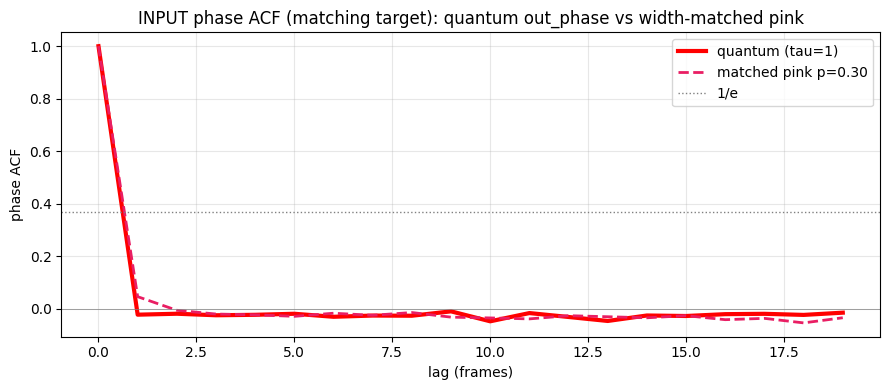

  [declick] interpolated 54 samples (0.26%) at 1 intra-frame offsets
classical rendered (stft route): ['classical_pink']   pink_phase=True pink_amp=True
classical_pink     rms=0.2325  -> output/dependent_trajectory/classical_pink.wav


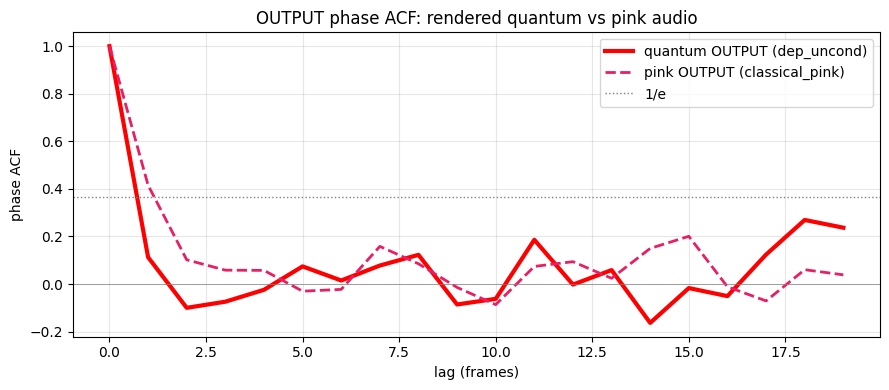

In [7]:
# ── Classical PINK rival, ACF-WIDTH-MATCHED to the quantum ─────────────────
# The quantum phase has power-law (pink-like) temporal memory. Measure its phase
# autocorrelation length tau_q, then build a 1/f^p pink phase whose ACF decays to
# 1/e at the SAME lag -> a width-matched classical rival. Rendered by the SAME
# route as the quantum output: STFT mode -> inverse-STFT (pink only);
# SMS mode -> SMS engine (on the SMS synthesis), alongside frozen.
CL_SEED = 0

def phase_acf(ph, max_lag):                       # avg phase autocorrelation over bins
    x = ph - ph.mean(0); v = (x**2).mean(0); v = np.where(v < 1e-12, np.nan, v)
    nf = ph.shape[0]
    return np.array([np.nanmean((x[:nf-l]*x[l:]).mean(0) / v) for l in range(max_lag)])

def corr_len(acf):                                # lag where ACF first drops below 1/e
    b = np.where(acf < 1/np.e)[0]; return int(b[0]) if len(b) else len(acf)

def pink_field(nf, nb, p, seed=0):                # 1/f^p noise per bin, standardized
    rng = np.random.default_rng(seed); w = rng.standard_normal((nf, nb))
    f = np.fft.rfftfreq(nf).copy(); f[0] = f[1] if len(f) > 1 else 1.0
    x = np.fft.irfft(np.fft.rfft(w, axis=0) / (f[:, None]**(p/2)), n=nf, axis=0)
    return (x - x.mean(0)) / (x.std(0) + 1e-9)

def pink_phase_p(nf, nb, p, seed=0):              # pink field wrapped into a phase
    return ((np.pi/2)*pink_field(nf, nb, p, seed) + np.pi) % (2*np.pi) - np.pi   # pi/2 scale: tau controllable, not wrap-dominated

def frozen_phase(nf, nb, seed=0):                 # SMS-mode extra rival: phase frozen across frames
    rng = np.random.default_rng(seed); return np.tile(2*np.pi*rng.random(nb) - np.pi, (nf, 1))

# 1) quantum phase ACF -> correlation length
max_lag = min(50, num_frames // 2)
q_acf = phase_acf(out_phase['uncond'], max_lag); tau_q = corr_len(q_acf)

# 2) match: pick exponent p so pink ACF reaches 1/e at the same lag as the quantum
_ps = np.linspace(0.3, 3.0, 19)
PINK_P = float(min(_ps, key=lambda p: abs(corr_len(phase_acf(pink_phase_p(num_frames, num_bins, p, CL_SEED), max_lag)) - tau_q)))
pink_ph = pink_phase_p(num_frames, num_bins, PINK_P, CL_SEED); pink_acf = phase_acf(pink_ph, max_lag)
print(f'quantum ACF tau={tau_q} frames  ->  matched pink exponent p={PINK_P:.2f}  (pink tau={corr_len(pink_acf)})')

# 3) overlay the two ACFs to confirm the width match
plt.figure(figsize=(9,4))
plt.plot(range(max_lag), q_acf, 'r-', lw=3, label=f'quantum (tau={tau_q})')
plt.plot(range(max_lag), pink_acf, '--', color='#E91E63', lw=2, label=f'matched pink p={PINK_P:.2f}')
plt.axhline(1/np.e, color='gray', ls=':', lw=1, label='1/e'); plt.axhline(0, color='gray', lw=0.5)
plt.xlabel('lag (frames)'); plt.ylabel('phase ACF'); plt.title('INPUT phase ACF (matching target): quantum out_phase vs width-matched pink')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'pink_acf_match.png'), dpi=140, bbox_inches='tight'); plt.show()

# 4) what the classical reconstruction uses (mirrors USE_QUANTUM_*): pink vs original
cl_phase = pink_ph if USE_CLASSICAL_PHASE else in_phase
if USE_CLASSICAL_AMP:                             # inject pink fluctuations on the magnitude
    cl_mag = np.clip(in_mag * (1.0 + 0.5*pink_field(num_frames, num_bins, PINK_P, CL_SEED+1)), 0.0, None)
else:
    cl_mag = in_mag

# 5) render by the same route as the quantum output
def _istft(mag, phase):
    return qam.STFT.stftSynth(20*np.log10(np.maximum(mag, 1e-10)), phase, ana['N_stoc'], ana['H'])

if RESIDUAL_INPUT == 'sms':                        # SMS route: SMS engine (on the SMS synthesis), + frozen rival
    results['classical_pink'],   _ = synth_full_stft(cl_mag, cl_phase, uqa=True, uqp=True, usp=CONDITION_HARMONIC_PHASE)
    results['classical_frozen'], _ = synth_full_stft(in_mag, frozen_phase(num_frames, num_bins, CL_SEED), usp=CONDITION_HARMONIC_PHASE)
    _rendered = ['classical_pink', 'classical_frozen']
else:                                              # STFT route: inverse-STFT, pink only
    results['classical_pink'] = _istft_declick(cl_mag, cl_phase); results.pop('classical_frozen', None)
    _rendered = ['classical_pink']

print(f'classical rendered ({RESIDUAL_INPUT} route): {_rendered}   pink_phase={USE_CLASSICAL_PHASE} pink_amp={USE_CLASSICAL_AMP}')
for _nm in _rendered:
    _p = os.path.join(OUT_DIR, f'{_nm}.wav'); soundfile.write(_p, results[_nm].astype(np.float32), fs)
    print(f'{_nm:18s} rms={np.sqrt(np.mean(results[_nm]**2)):.4f}  -> {_p}'); display(Audio(results[_nm], rate=fs))

# 6) OUTPUT phase ACF: does the width-match carry through to the rendered audio? (re-analyse the outputs)
_qo = qam.STFT.stftAnal(results['dep_uncond'],   _hann(ana['N_stoc']), ana['N_stoc'], ana['H'])[1]
_po = qam.STFT.stftAnal(results['classical_pink'], _hann(ana['N_stoc']), ana['N_stoc'], ana['H'])[1]
qo_acf, po_acf = phase_acf(_qo, max_lag), phase_acf(_po, max_lag)
plt.figure(figsize=(9,4))
plt.plot(range(max_lag), qo_acf, 'r-', lw=3, label='quantum OUTPUT (dep_uncond)')
plt.plot(range(max_lag), po_acf, '--', color='#E91E63', lw=2, label='pink OUTPUT (classical_pink)')
plt.axhline(1/np.e, color='gray', ls=':', lw=1, label='1/e'); plt.axhline(0, color='gray', lw=0.5)
plt.xlabel('lag (frames)'); plt.ylabel('phase ACF'); plt.title('OUTPUT phase ACF: rendered quantum vs pink audio')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'pink_acf_output.png'), dpi=140, bbox_inches='tight'); plt.show()


### 6b. Classical PINK rival **v2** — carrier-preserving, deviation-matched

The v1 rival **replaces** the STFT phase wholesale, which destroys each bin's
deterministic carrier advance (2π·f_k·H/fs per frame). Measured on the last run:
carrier coherence R = |⟨e^{i(Δφ−Δφ_in)}⟩| is **0.03** for v1's phase vs **0.73**
for the quantum output — v1 is maximally OLA-inconsistent, which is why it sounds
so much clickier than the quantum render (~2× the click events). That clickiness
is a *render artifact of the rival's construction*, not a quantum/classical
discriminator — an unfair tell.

v2 mimics what the quantum channel actually does: it keeps the input carrier and
adds a pink **deviation** φ = φ_in + dev, with BOTH statistics matched to the
measured quantum deviation field dev_q = wrap(φ_q − φ_in):
its depth (rms, ≈1.9 rad on the last run) and its smoothness (per-frame step rms
≈0.88 rad ⇒ lag-1 autocorrelation ≈0.89 — the quantum deviation is a SLOW random
walk, ~8-frame memory: that slow per-bin FM wander is the "spacy" texture).
Amplitude gets the same treatment (multiplicative pink at the measured AM depth).
A fair listener test is then quantum-vs-v2; keep v1 only as the old reference.


quantum deviation: depth=2.82 rad, step=0.53 rad -> field rho1 target=0.983
matched pink exponent p=5.00 (field rho1=0.981)   [v1 replace-phase p=0.30]
amplitude depth = 0.54 (measured from quantum out/in; v1 used 0.50)
  [declick] interpolated 57 samples (0.28%) at 1 intra-frame offsets
carrier coherence R: quantum=0.561  pink v2=0.856  pink v1=0.017  input=1.000


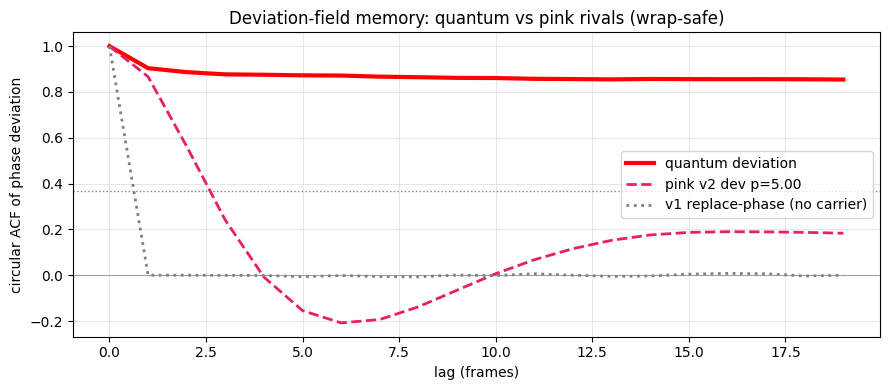

classical_pink     rms=0.2325  -> output/dependent_trajectory/classical_pink.wav


classical_pink2    rms=0.2439  -> output/dependent_trajectory/classical_pink2.wav


In [8]:
# ── Classical PINK rival v2: CARRIER-PRESERVING, deviation-statistics-matched ──
# quantum phase deviation from the input carrier (wrap-safe)
dev_q = np.angle(np.exp(1j*(out_phase['uncond'] - in_phase)))
st_q  = np.angle(np.exp(1j*np.diff(dev_q, axis=0)))
PM_DEPTH = float(np.sqrt((dev_q**2).mean()))          # deviation rms (rad)
PM_STEP  = float(np.sqrt((st_q**2).mean()))           # per-frame step rms (rad)
rho1_target = float(np.clip(1.0 - (PM_STEP/max(PM_DEPTH,1e-9))**2/2.0, 0.0, 0.999))

_grid = np.linspace(0.5, 5.0, 46)
def _field_rho1(p):
    x = pink_field(num_frames, num_bins, p, CL_SEED+3)
    return float(np.corrcoef(x[:-1].ravel(), x[1:].ravel())[0, 1])
PINK_P2 = float(min(_grid, key=lambda p: abs(_field_rho1(p) - rho1_target)))
print(f'quantum deviation: depth={PM_DEPTH:.2f} rad, step={PM_STEP:.2f} rad -> field rho1 target={rho1_target:.3f}')
print(f'matched pink exponent p={PINK_P2:.2f} (field rho1={_field_rho1(PINK_P2):.3f})   [v1 replace-phase p={PINK_P:.2f}]')

pink_dev = PM_DEPTH * pink_field(num_frames, num_bins, PINK_P2, CL_SEED+7)
cl_phase2 = (in_phase + pink_dev) if USE_CLASSICAL_PHASE else in_phase

# amplitude: multiplicative pink at the MEASURED quantum AM depth, same smoothness
_en = in_mag > 0.1*in_mag.max()
_ratio = (out_mag_n['uncond']*scale_per_bin[np.newaxis, :]) / np.maximum(in_mag, 1e-12)
AM_DEPTH = float(np.clip(np.std(_ratio[_en] - 1.0), 0.05, 1.0))
cl_mag2 = (np.clip(in_mag*(1.0 + AM_DEPTH*pink_field(num_frames, num_bins, PINK_P2, CL_SEED+8)), 0.0, None)
           if USE_CLASSICAL_AMP else in_mag)
print(f'amplitude depth = {AM_DEPTH:.2f} (measured from quantum out/in; v1 used 0.50)')

if RESIDUAL_INPUT == 'sms':
    results['classical_pink2'], _ = synth_full_stft(cl_mag2, cl_phase2, uqa=True, uqp=True, usp=CONDITION_HARMONIC_PHASE)
else:
    results['classical_pink2'] = _istft_declick(cl_mag2, cl_phase2)

# fairness metrics: carrier coherence R (energetic bins) — should now be ~equal
def _carrier_R(ph):
    z = np.exp(1j*(np.diff(ph, axis=0) - np.diff(in_phase, axis=0)))
    en = in_mag.mean(0) > 0.05*in_mag.mean(0).max()
    return float(np.abs(z[:, en].mean()))
print(f'carrier coherence R: quantum={_carrier_R(out_phase["uncond"]):.3f}  '
      f'pink v2={_carrier_R(cl_phase2):.3f}  pink v1={_carrier_R(cl_phase):.3f}  input=1.000')

# circular ACF of the DEVIATION fields (wrap-safe): quantum vs v2 vs v1-equivalent
def _dev_cacf(d, max_lag):
    out = np.empty(max_lag); out[0] = 1.0
    for l in range(1, max_lag):
        out[l] = float(np.cos(d[l:] - d[:-l]).mean())
    return out
plt.figure(figsize=(9, 4))
plt.plot(range(max_lag), _dev_cacf(dev_q, max_lag), 'r-', lw=3, label='quantum deviation')
plt.plot(range(max_lag), _dev_cacf(pink_dev, max_lag), '--', color='#E91E63', lw=2, label=f'pink v2 dev p={PINK_P2:.2f}')
_v1dev = np.angle(np.exp(1j*(pink_ph - in_phase)))
plt.plot(range(max_lag), _dev_cacf(_v1dev, max_lag), ':', color='gray', lw=2, label='v1 replace-phase (no carrier)')
plt.axhline(1/np.e, color='gray', ls=':', lw=1); plt.axhline(0, color='gray', lw=0.5)
plt.xlabel('lag (frames)'); plt.ylabel('circular ACF of phase deviation')
plt.title('Deviation-field memory: quantum vs pink rivals (wrap-safe)')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'pink_dev_acf.png'), dpi=140, bbox_inches='tight'); plt.show()

for _nm in ['classical_pink', 'classical_pink2']:
    if _nm in results:
        _p = os.path.join(OUT_DIR, f'{_nm}.wav'); soundfile.write(_p, results[_nm].astype(np.float32), fs)
        print(f'{_nm:18s} rms={np.sqrt(np.mean(results[_nm]**2)):.4f}  -> {_p}')
        display(Audio(results[_nm], rate=fs))


## 7. Listen & export

In [9]:
order = ['original', 'classical_frozen', 'classical_pink', 'classical_pink2', 'full_stft_colour',
         'dep_uncond', 'dep_cond0', 'dep_cond1']
for name in [n for n in order if n in results]:
    sig = results[name]
    p = os.path.join(OUT_DIR, f'{name}.wav')
    soundfile.write(p, sig.astype(np.float32), fs)
    rms = np.sqrt(np.mean(sig**2))
    print(f'{name:18s}  rms={rms:.4f}   -> {p}')
    display(Audio(sig, rate=fs))


original            rms=0.2500   -> output/dependent_trajectory/original.wav


classical_pink      rms=0.2325   -> output/dependent_trajectory/classical_pink.wav


classical_pink2     rms=0.2439   -> output/dependent_trajectory/classical_pink2.wav


full_stft_colour    rms=0.2448   -> output/dependent_trajectory/full_stft_colour.wav


dep_uncond          rms=0.2517   -> output/dependent_trajectory/dep_uncond.wav


dep_cond0           rms=0.2517   -> output/dependent_trajectory/dep_cond0.wav


dep_cond1           rms=0.2517   -> output/dependent_trajectory/dep_cond1.wav


## 8. Spectrograms

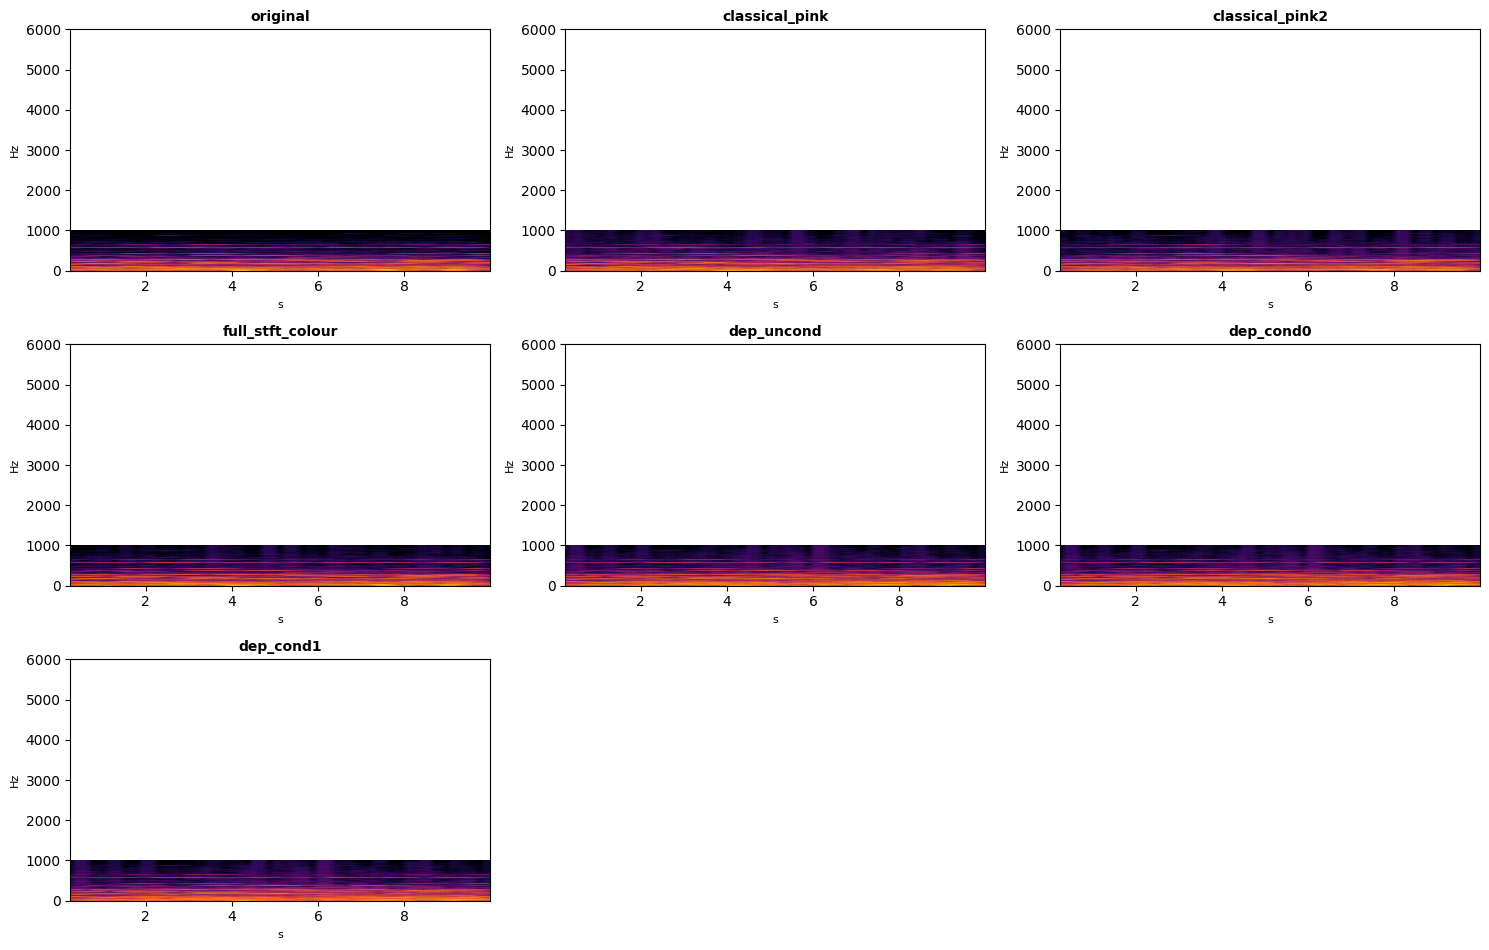

In [10]:
def plot_specs(results, order, fs, max_freq=6000, db_range=80):
    n = len(order); cols = 3; rows = int(np.ceil(n/cols))
    fig, ax = plt.subplots(rows, cols, figsize=(5*cols, 3.2*rows)); ax = ax.flatten()
    for i, name in enumerate(order):
        f, t, Sxx = scipy_spectrogram(results[name], fs=fs, nperseg=1024, noverlap=768)
        SdB = 10*np.log10(Sxx + 1e-12); vmax = SdB.max()
        ax[i].pcolormesh(t, f, SdB, vmin=vmax-db_range, vmax=vmax, shading='gouraud', cmap='inferno')
        ax[i].set_ylim(0, max_freq); ax[i].set_title(name, fontsize=10, fontweight='bold')
        ax[i].set_xlabel('s', fontsize=8); ax[i].set_ylabel('Hz', fontsize=8)
    for i in range(n, len(ax)): ax[i].axis('off')
    plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, 'spectrograms.png'), dpi=140, bbox_inches='tight')
    plt.show()

plot_specs(results, [n for n in order if n in results], fs)

## 9. The delayed choice, made audible & visible

`cond0` and `cond1` are the **same buffered frames re-painted by two different
future probe outcomes**. They differ from each other and from `uncond` — that
difference *is* the retrodictive, temporally-entangled colouring (certified
elsewhere by the negative two-time PDM eigenvalue).

Audible difference (RMS):
  cond0 vs cond1   : 0.00000
  cond0 vs uncond  : 0.00000
  cond1 vs uncond  : 0.00000
  (signal RMS dep_uncond = 0.25171)


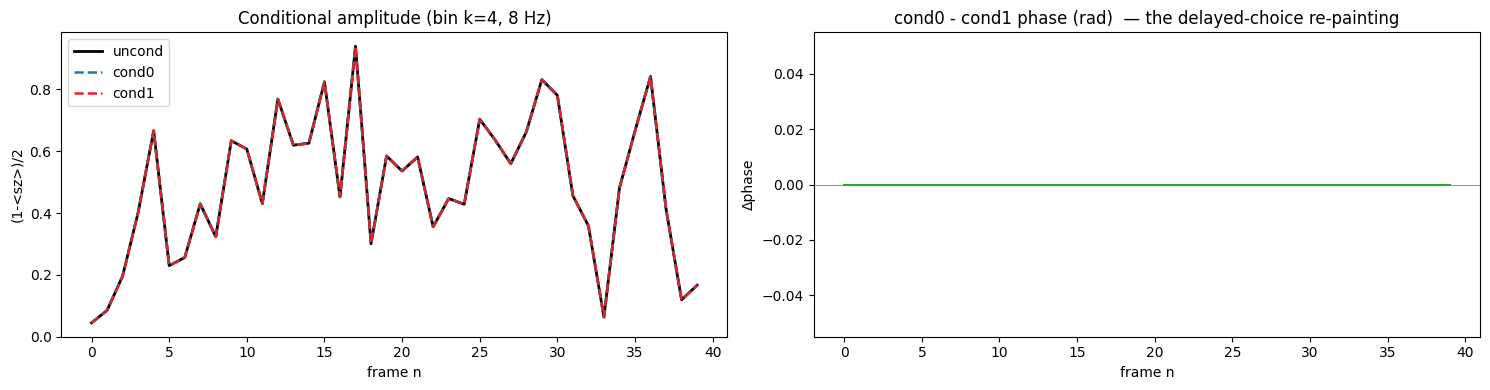

In [11]:
def rms(a, b):
    m = min(len(a), len(b)); return float(np.sqrt(np.mean((a[:m]-b[:m])**2)))

print('Audible difference (RMS):')
print(f'  cond0 vs cond1   : {rms(results["dep_cond0"], results["dep_cond1"]):.5f}')
print(f'  cond0 vs uncond  : {rms(results["dep_cond0"], results["dep_uncond"]):.5f}')
print(f'  cond1 vs uncond  : {rms(results["dep_cond1"], results["dep_uncond"]):.5f}')
print(f'  (signal RMS dep_uncond = {np.sqrt(np.mean(results["dep_uncond"]**2)):.5f})')

# per-bin conditional amplitude envelope at a representative bin
k = int(np.argmax(in_mag.mean(axis=0)[1:]) + 1)   # loudest non-DC bin
fig, axx = plt.subplots(1, 2, figsize=(15, 4))
axx[0].plot(out_mag_n['uncond'][:, k], 'k-', lw=2, label='uncond')
axx[0].plot(out_mag_n['cond0'][:, k], 'C0--', lw=1.8, label='cond0')
axx[0].plot(out_mag_n['cond1'][:, k], 'C3--', lw=1.8, label='cond1')
axx[0].set_title(f'Conditional amplitude (bin k={k}, {freq_bins[k]:.0f} Hz)')
axx[0].set_xlabel('frame n'); axx[0].set_ylabel('(1-<sz>)/2'); axx[0].legend()

dphi = (out_phase['cond0'][:, k] - out_phase['cond1'][:, k] + np.pi) % (2*np.pi) - np.pi
axx[1].plot(dphi, 'C2-'); axx[1].axhline(0, color='gray', lw=0.6)
axx[1].set_title('cond0 - cond1 phase (rad)  — the delayed-choice re-painting')
axx[1].set_xlabel('frame n'); axx[1].set_ylabel('Δphase')
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, 'delayed_choice_bin.png'), dpi=140, bbox_inches='tight')
plt.show()

## 10. Stochastic-only variant (clean tone) — the right fix

The cells above ran the trajectory on **all** bins (full-STFT), so the stochastic
collapse also overwrote the **tonal** bins -> massive noise. Here we colour only
the **stochastic-only** residual bins (as Mode III does) and leave the sinusoidal
tracks untouched. Same delayed-choice conditional readout, but you should now hear
a clean Glass tone whose **residual hiss** is re-painted by the delayed choice.

In [12]:
# from quantum_audio_master import get_stochastic_only_bins
# stoch_bins = np.where(get_stochastic_only_bins(ana['sin_freqs'], freq_bins, None))[0]
# print(f"stochastic-only bins: {len(stoch_bins)}/{num_bins}")

# t0 = time.time()
# som, soph, sscale, sdiag = dependent_colour_transform_per_bin(
#     ana['Xr_mag'], ana['Xr_phase'], freq_bins, stoch_bins, DELAY, PHASE,
#     n_traj=N_TRAJ, base_seed=BASE_SEED, gamma_x=GAMMA, gamma_z=GAMMA_Z, interaction=INTERACTION,
#     freq_scale=FREQ_SCALE, measurement_basis=BASIS, amp_gain=AMP_GAIN, verbose=True)
# print(f"stochastic-only done: {time.time()-t0:.1f}s")

# stoch_res = {}
# for v in ['uncond', 'cond0', 'cond1']:
#     oms = som[v] * sscale[np.newaxis, :]
#     s = synthesise_sms(ana, res_mag=oms, res_phase=soph[v],
#                        use_quantum_amp=USE_QUANTUM_AMP, use_quantum_phase=USE_QUANTUM_PHASE, softclip=True,
#                        win_norm_dB_override=ana['win_norm_dB'])
#     stoch_res['dep_stoch_' + v] = s['y_quantum']
# # 'original' = ANALYZED input (un-processed residual) through the SAME synthesis path
# stoch_res['original'] = synthesise_sms(ana, res_mag=ana['Xr_mag'], res_phase=ana['Xr_phase'],
#                                        use_quantum_amp=USE_QUANTUM_AMP, use_quantum_phase=USE_QUANTUM_PHASE,
#                                        softclip=True, win_norm_dB_override=ana['win_norm_dB'])['y_quantum']

# tag = 'ampON' if USE_QUANTUM_AMP else 'ampOFF'
# for name in ['original', 'dep_stoch_uncond', 'dep_stoch_cond0', 'dep_stoch_cond1']:
#     sig = stoch_res[name]
#     soundfile.write(os.path.join(OUT_DIR, f"{name}_stoch_{tag}.wav"), sig.astype(np.float32), fs)
#     print(f"{name:18s} rms={np.sqrt(np.mean(sig**2)):.4f}")
#     display(Audio(sig, rate=fs))

# m = min(len(stoch_res['dep_stoch_cond0']), len(stoch_res['dep_stoch_cond1']))
# c01 = float(np.sqrt(np.mean((stoch_res['dep_stoch_cond0'][:m] - stoch_res['dep_stoch_cond1'][:m])**2)))
# print(f"cond0 vs cond1 RMS: {c01:.5f}  (USE_QUANTUM_AMP={USE_QUANTUM_AMP})")

## 11. Time Stretching

Three types of time stretch applied to all outputs:

1. **TS1 — Colored stretch** (`time_stretch`): linear-interpolation resampling.
   Changes pitch AND duration. Post-processing on audio.

2. **TS2 — Clean phase-vocoder stretch** (`librosa.effects.time_stretch`):
   Preserves pitch, changes duration only. Post-processing on audio.

3. **TS3 — Quantum frame stretch**: interpolates the quantum-decoded magnitude
   and phase matrices in the STFT domain *before* synthesis. This stretches the
   quantum evolution itself — the collision-model dynamics play out slower (or faster)
   while the synthesis hop size stays fixed. Analogous to stretching the energy
   spacing of the open system: each collision step now maps to fewer audio samples,
   spreading the quantum correlations over a longer time window.

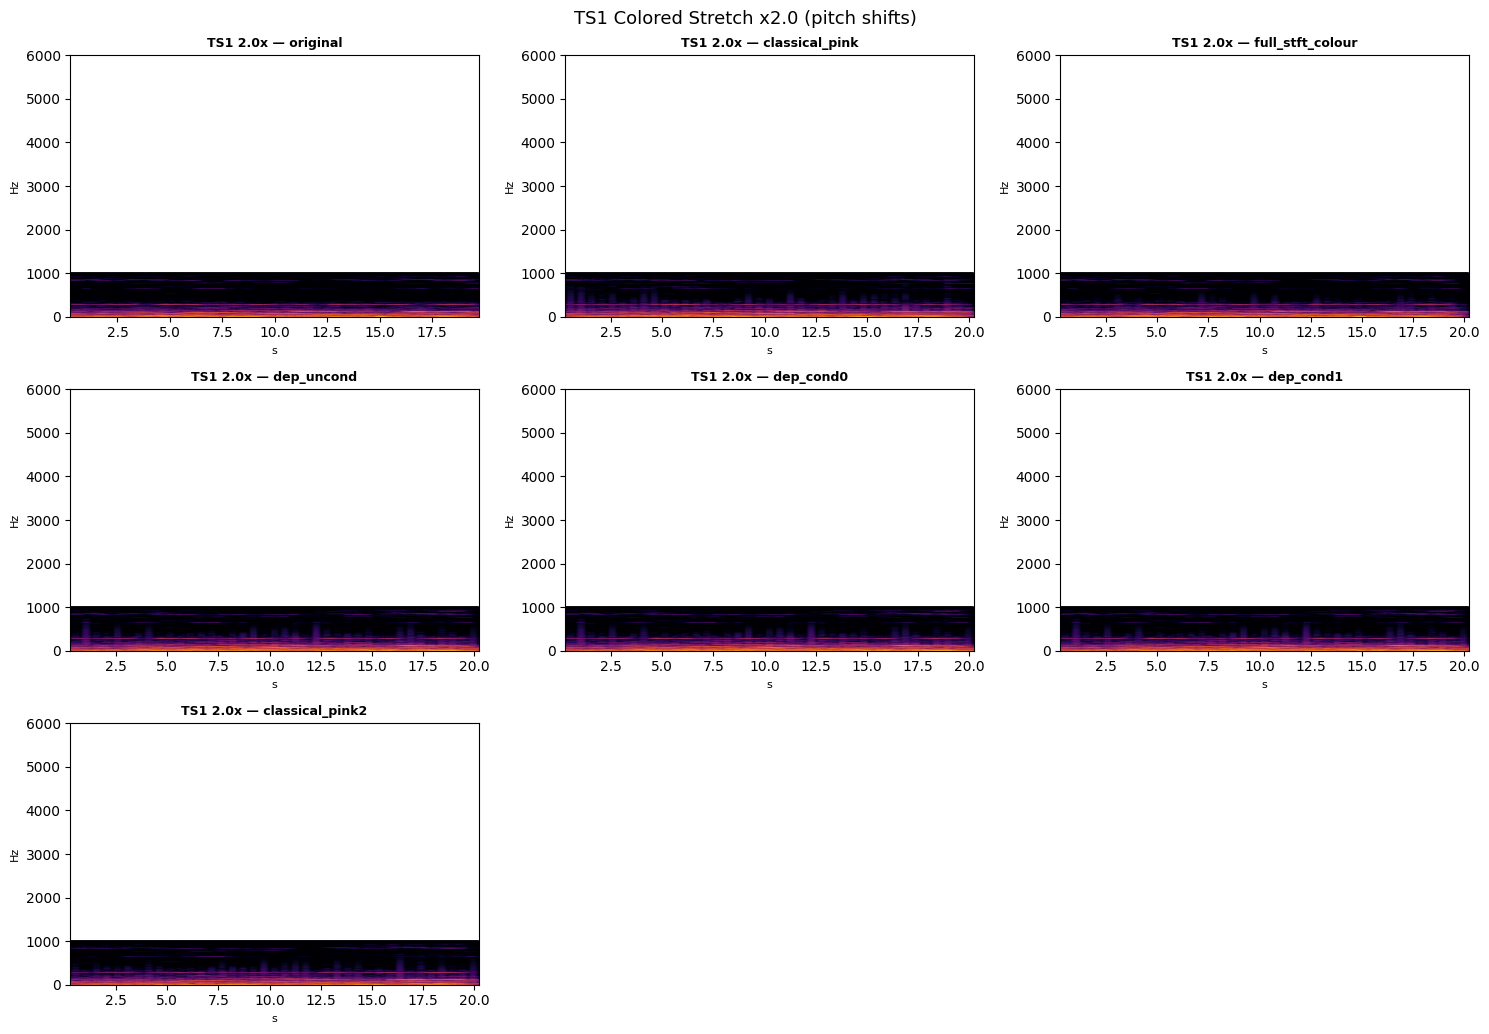

TS1 original           20.00s  rms=0.2524


TS1 classical_pink     20.48s  rms=0.2319


TS1 full_stft_colour   20.48s  rms=0.2442


TS1 dep_uncond         20.48s  rms=0.2509


TS1 dep_cond0          20.48s  rms=0.2509


TS1 dep_cond1          20.48s  rms=0.2509


TS1 classical_pink2    20.48s  rms=0.2431


In [13]:
# ═══════════════════════════════════════════════════════════════
# 11a. TS1 — COLORED STRETCH (resampling, changes pitch + duration)
# ═══════════════════════════════════════════════════════════════
from quantum_audio_master import time_stretch

TS1_FACTOR = 2.0  # 2x = half speed, octave down

ts1 = {}
ts1_targets = {
    'original': data,
    'classical_pink': results['classical_pink'],
    'full_stft_colour': results['full_stft_colour'],
    'dep_uncond': results['dep_uncond'],
    'dep_cond0': results['dep_cond0'],
    'dep_cond1': results['dep_cond1'],
}
if 'classical_pink2' in results:   # carrier-preserving deviation-matched rival (cell 6b)
    ts1_targets['classical_pink2'] = results['classical_pink2']
# nan_to_num kept as a guard only: full_stft_colour is NaN-free at phase=pi (NaN was a legacy of phase=pi/2 runs — non-Hermitian V + no renormalisation in the deterministic path)
ts1_targets = {k: np.nan_to_num(np.asarray(v, dtype=float)) for k, v in ts1_targets.items()}

for name, sig in ts1_targets.items():
    ts1[name] = time_stretch(sig, TS1_FACTOR)

# Spectrograms
ncol = 3; nrow = int(np.ceil(len(ts1) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(5*ncol, 3.5*nrow))
axes = np.atleast_1d(axes).flatten()
for i, (name, sig) in enumerate(ts1.items()):
    f, t, Sxx = scipy_spectrogram(sig, fs=fs, nperseg=1024, noverlap=768)
    SdB = 10 * np.log10(Sxx + 1e-12); vmax = SdB.max()
    axes[i].pcolormesh(t, f, SdB, vmin=vmax-80, vmax=vmax, shading='gouraud', cmap='inferno')
    axes[i].set_ylim(0, 6000)
    axes[i].set_title(f'TS1 {TS1_FACTOR}x — {name}', fontsize=9, fontweight='bold')
    axes[i].set_xlabel('s', fontsize=8); axes[i].set_ylabel('Hz', fontsize=8)
for _j in range(len(ts1), len(axes)): axes[_j].axis('off')
plt.suptitle(f'TS1 Colored Stretch x{TS1_FACTOR} (pitch shifts)', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'ts1_spectrograms.png'), dpi=140, bbox_inches='tight')
plt.show()

# Audio playback + export
for name, sig in ts1.items():
    p = os.path.join(OUT_DIR, f'ts1_{name}.wav')
    soundfile.write(p, sig.astype(np.float32), fs)
    print(f'TS1 {name:18s} {len(sig)/fs:.2f}s  rms={np.sqrt(np.mean(sig**2)):.4f}')
    display(Audio(sig, rate=fs))

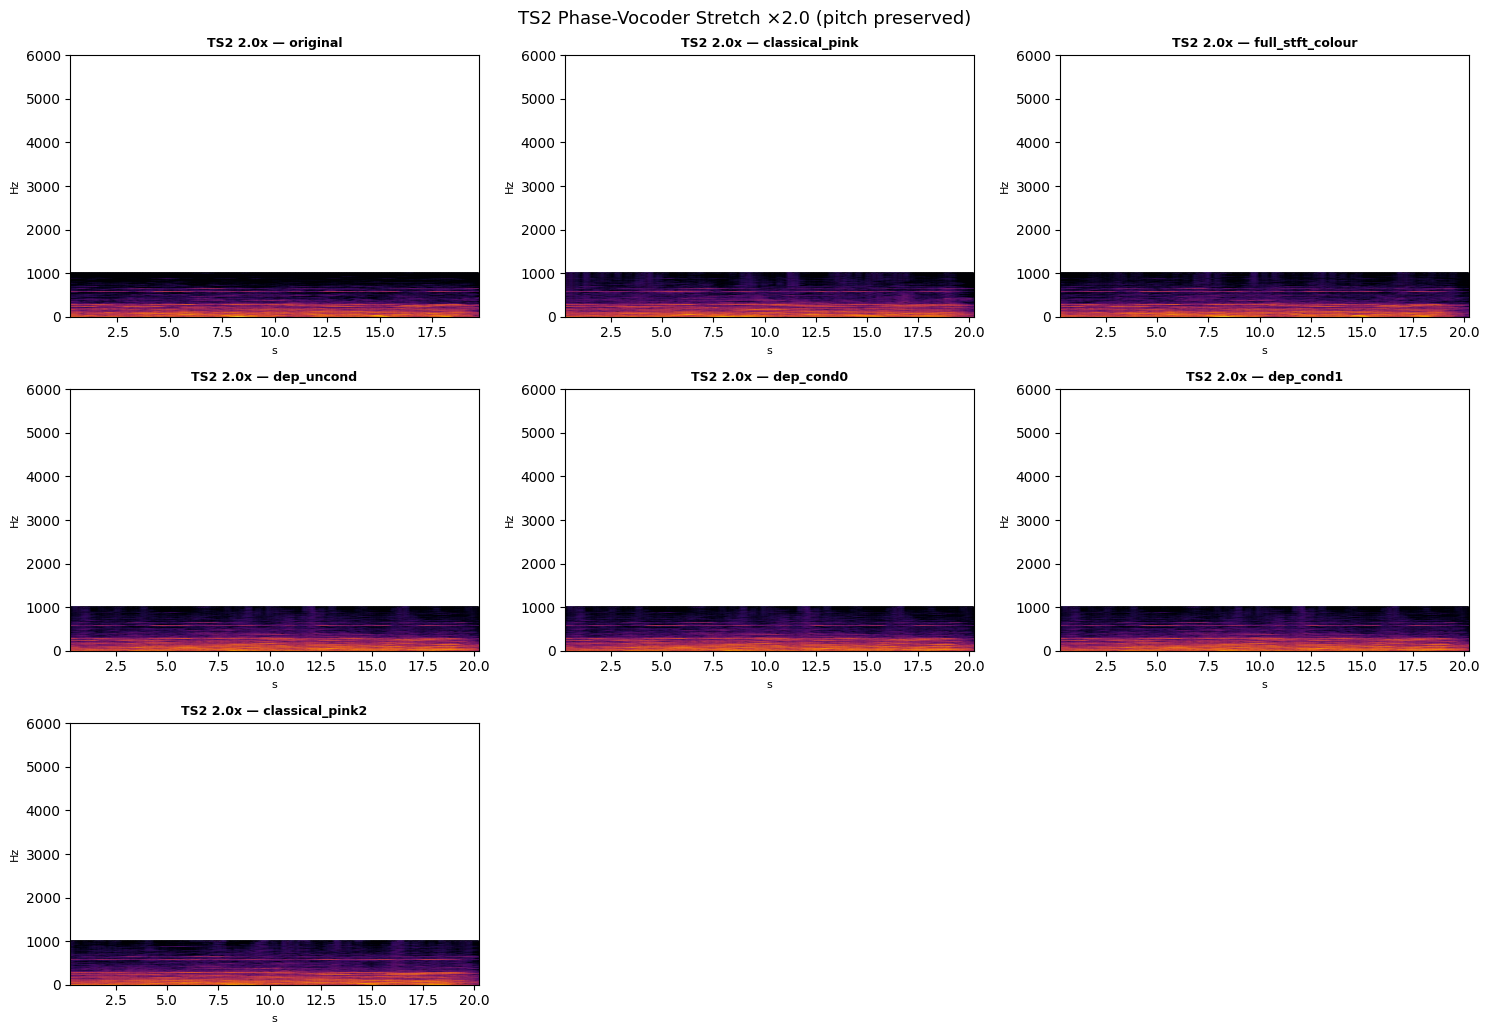

TS2 original           20.00s  rms=0.2043


TS2 classical_pink     20.48s  rms=0.1923


TS2 full_stft_colour   20.48s  rms=0.2106


TS2 dep_uncond         20.48s  rms=0.1930


TS2 dep_cond0          20.48s  rms=0.1930


TS2 dep_cond1          20.48s  rms=0.1930


TS2 classical_pink2    20.48s  rms=0.1894


In [14]:
#### ═══════════════════════════════════════════════════════════════
# 11b. TS2 — CLEAN PHASE-VOCODER STRETCH (preserves pitch)
# ═══════════════════════════════════════════════════════════════
import librosa

TS2_FACTOR = 2.0  # 2x = double duration, same pitch

ts2 = {}
for name, sig in ts1_targets.items():
    ts2[name] = librosa.effects.time_stretch(sig.astype(np.float32), rate=1.0/TS2_FACTOR)

# Spectrograms
ncol = 3; nrow = int(np.ceil(len(ts2) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(5*ncol, 3.5*nrow))
axes = np.atleast_1d(axes).flatten()
for i, (name, sig) in enumerate(ts2.items()):
    f, t, Sxx = scipy_spectrogram(sig, fs=fs, nperseg=1024, noverlap=768)
    SdB = 10 * np.log10(Sxx + 1e-12); vmax = SdB.max()
    axes[i].pcolormesh(t, f, SdB, vmin=vmax-80, vmax=vmax, shading='gouraud', cmap='inferno')
    axes[i].set_ylim(0, 6000)
    axes[i].set_title(f'TS2 {TS2_FACTOR}x — {name}', fontsize=9, fontweight='bold')
    axes[i].set_xlabel('s', fontsize=8); axes[i].set_ylabel('Hz', fontsize=8)
for _j in range(len(ts2), len(axes)): axes[_j].axis('off')
plt.suptitle(f'TS2 Phase-Vocoder Stretch ×{TS2_FACTOR} (pitch preserved)', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'ts2_spectrograms.png'), dpi=140, bbox_inches='tight')
plt.show()

# Audio playback + export
for name, sig in ts2.items():
    p = os.path.join(OUT_DIR, f'ts2_{name}.wav')
    soundfile.write(p, sig.astype(np.float32), fs)
    print(f'TS2 {name:18s} {len(sig)/fs:.2f}s  rms={np.sqrt(np.mean(sig**2)):.4f}')
    display(Audio(sig, rate=fs))

### 11c. TS3 — Quantum frame stretch (was documented but never implemented)

Interpolates the **quantum-decoded** magnitude and phase matrices along the frame
axis *before* synthesis, with the synthesis hop unchanged: each collision step now
maps to more audio time, spreading the channel's frame-domain correlations (delay
comb, collapse noise) over a longer window WITHOUT touching pitch structure the
way TS1 does or re-analysing the audio the way TS2 does. Phase is interpolated on
the unit circle (via cos/sin) — never linearly across a wrap.


  [declick] interpolated 81 samples (0.20%) at 1 intra-frame offsets
  [declick] interpolated 81 samples (0.20%) at 1 intra-frame offsets
  [declick] interpolated 81 samples (0.20%) at 1 intra-frame offsets
  [declick] interpolated 117 samples (0.29%) at 2 intra-frame offsets


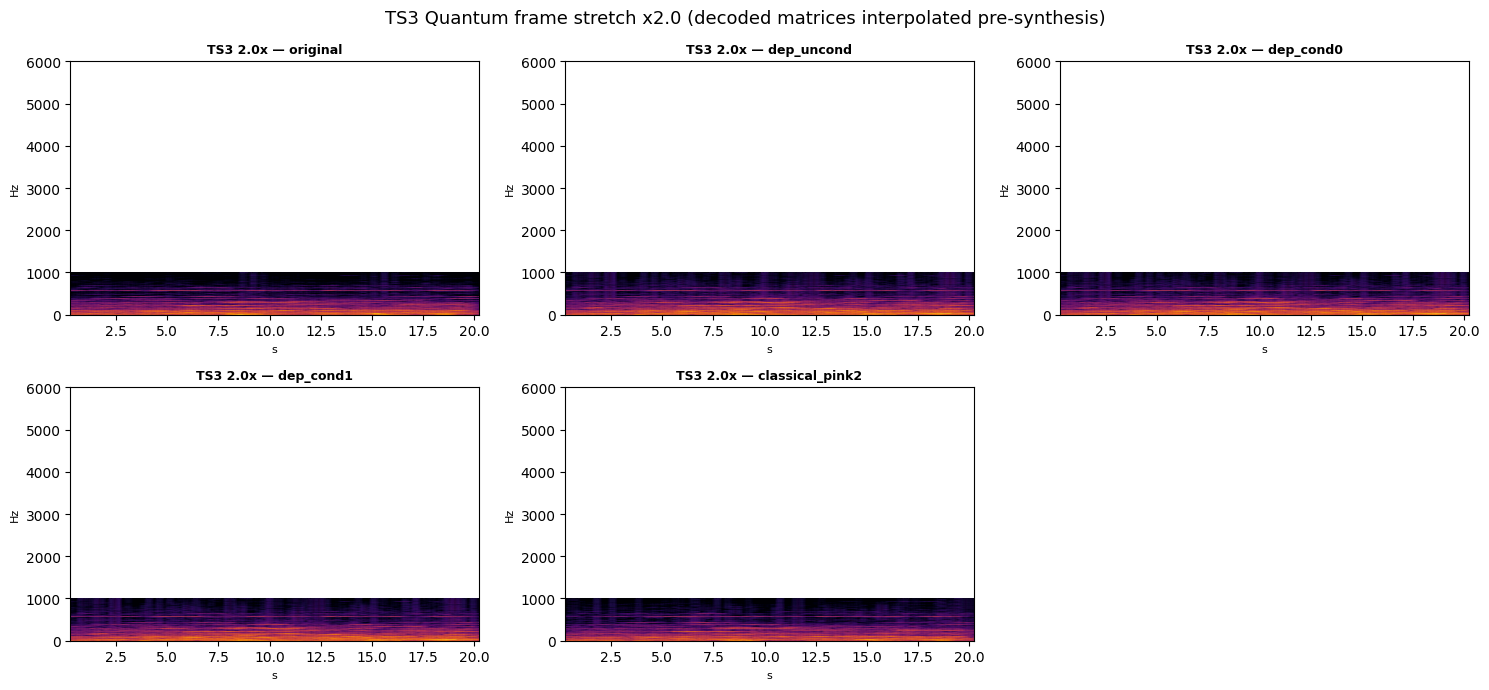

TS3 original           20.48s  rms=0.2314


TS3 dep_uncond         20.48s  rms=0.2375


TS3 dep_cond0          20.48s  rms=0.2375


TS3 dep_cond1          20.48s  rms=0.2375


TS3 classical_pink2    20.48s  rms=0.2396


In [15]:
# ═══════════════════════════════════════════════════════════════
# 11c. TS3 — QUANTUM FRAME STRETCH (interpolate decoded matrices BEFORE synthesis)
# ═══════════════════════════════════════════════════════════════
TS3_FACTOR = 2.0

def _stretch_mat(mat, fac):
    T0 = mat.shape[0]; T2 = int(round(T0*fac))
    src = np.linspace(0, T0-1, T2); i0 = np.floor(src).astype(int)
    i1 = np.minimum(i0+1, T0-1); w = (src-i0)[:, None]
    return (1-w)*mat[i0] + w*mat[i1]

def _stretch_phase(ph_mat, fac):   # interpolate on the circle, not across wraps
    z = np.exp(1j*ph_mat)
    return np.angle(_stretch_mat(z.real, fac) + 1j*_stretch_mat(z.imag, fac))

ts3 = {}
ts3['original'] = qam.STFT.stftSynth(
    20*np.log10(np.maximum(_stretch_mat(in_mag, TS3_FACTOR), 1e-10)),
    _stretch_phase(in_phase, TS3_FACTOR), ana['N_stoc'], ana['H'])
for v in ['uncond', 'cond0', 'cond1']:
    m2 = _stretch_mat(out_mag_n[v]*scale_per_bin[np.newaxis, :], TS3_FACTOR)
    p2 = _stretch_phase(out_phase[v], TS3_FACTOR)
    ts3['dep_'+v] = _declick(qam.STFT.stftSynth(20*np.log10(np.maximum(m2, 1e-10)), p2,
                                                ana['N_stoc'], ana['H']), ana['H'])
if 'classical_pink2' in results:   # stretch the v2 pink fields the same way, for a fair stretched rival
    ts3['classical_pink2'] = _declick(qam.STFT.stftSynth(
        20*np.log10(np.maximum(_stretch_mat(cl_mag2, TS3_FACTOR), 1e-10)),
        _stretch_phase(cl_phase2, TS3_FACTOR), ana['N_stoc'], ana['H']), ana['H'])

ncol = 3; nrow = int(np.ceil(len(ts3) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(5*ncol, 3.5*nrow))
axes = np.atleast_1d(axes).flatten()
for i, (name, sig) in enumerate(ts3.items()):
    f, t, Sxx = scipy_spectrogram(sig, fs=fs, nperseg=1024, noverlap=768)
    SdB = 10*np.log10(Sxx + 1e-12); vmax = SdB.max()
    axes[i].pcolormesh(t, f, SdB, vmin=vmax-80, vmax=vmax, shading='gouraud', cmap='inferno')
    axes[i].set_ylim(0, 6000)
    axes[i].set_title(f'TS3 {TS3_FACTOR}x — {name}', fontsize=9, fontweight='bold')
    axes[i].set_xlabel('s', fontsize=8); axes[i].set_ylabel('Hz', fontsize=8)
for _j in range(len(ts3), len(axes)): axes[_j].axis('off')
plt.suptitle(f'TS3 Quantum frame stretch x{TS3_FACTOR} (decoded matrices interpolated pre-synthesis)', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'ts3_spectrograms.png'), dpi=140, bbox_inches='tight')
plt.show()

for name, sig in ts3.items():
    p = os.path.join(OUT_DIR, f'ts3_{name}.wav')
    soundfile.write(p, sig.astype(np.float32), fs)
    print(f'TS3 {name:18s} {len(sig)/fs:.2f}s  rms={np.sqrt(np.mean(sig**2)):.4f}')
    display(Audio(sig, rate=fs))


## 12. Export all audio (trackable names)

In [16]:
# ═══════════════════════════════════════════════════════════════
# Export EVERY rendered audio in this notebook (stochastic-only excluded — it's out).
# Names: <stem>__<render>__<param-tag>.wav  so each file is self-describing.
# ═══════════════════════════════════════════════════════════════
import re
stem = re.sub(r'[^A-Za-z0-9]+', '_', os.path.splitext(os.path.basename(AUDIO_PATH))[0])
tag  = f'd{DELAY}_{AMP_MODE}{AMP_POW if AMP_MODE=="power" else int(round(globals().get("AMP_GAIN_EFF", 0)))}_{BASIS}_{INTERACTION[:4]}_qa{int(USE_QUANTUM_AMP)}qp{int(USE_QUANTUM_PHASE)}'
EXPORT_DIR = os.path.join(OUT_DIR, 'export')
os.makedirs(EXPORT_DIR, exist_ok=True)

def _w(name, sig, rate=None):
    fn = os.path.join(EXPORT_DIR, name)
    soundfile.write(fn, np.asarray(sig, dtype=np.float32), int(rate or fs))
    return name

exported = []
exported.append(_w(f'{stem}__input_raw.wav', data))           # the analysed input itself
for name in sorted(results):                                  # all full-STFT renders
    exported.append(_w(f'{stem}__{name}__{tag}.wav', results[name]))

# time-stretched variants, if those cells have been run
for dct, lbl, facvar in [('ts1', 'ts1_resample', 'TS1_FACTOR'),
                         ('ts2', 'ts2_pvoc',     'TS2_FACTOR'),
                         ('ts3', 'ts3_qframe',   'TS3_FACTOR')]:
    d = globals().get(dct)
    if isinstance(d, dict):
        fac = globals().get(facvar, '')
        for name in sorted(d):
            exported.append(_w(f'{stem}__{lbl}x{fac}__{name}__{tag}.wav', d[name]))

print(f'exported {len(exported)} files -> {EXPORT_DIR}')
for fn in exported:
    print('  ', fn)


exported 28 files -> output/dependent_trajectory/export
   2807__input_raw.wav
   2807__classical_pink__d6_power0.45_x_beam_qa1qp1.wav
   2807__classical_pink2__d6_power0.45_x_beam_qa1qp1.wav
   2807__dep_cond0__d6_power0.45_x_beam_qa1qp1.wav
   2807__dep_cond1__d6_power0.45_x_beam_qa1qp1.wav
   2807__dep_uncond__d6_power0.45_x_beam_qa1qp1.wav
   2807__full_stft_colour__d6_power0.45_x_beam_qa1qp1.wav
   2807__original__d6_power0.45_x_beam_qa1qp1.wav
   2807__sms_standard__d6_power0.45_x_beam_qa1qp1.wav
   2807__ts1_resamplex2.0__classical_pink__d6_power0.45_x_beam_qa1qp1.wav
   2807__ts1_resamplex2.0__classical_pink2__d6_power0.45_x_beam_qa1qp1.wav
   2807__ts1_resamplex2.0__dep_cond0__d6_power0.45_x_beam_qa1qp1.wav
   2807__ts1_resamplex2.0__dep_cond1__d6_power0.45_x_beam_qa1qp1.wav
   2807__ts1_resamplex2.0__dep_uncond__d6_power0.45_x_beam_qa1qp1.wav
   2807__ts1_resamplex2.0__full_stft_colour__d6_power0.45_x_beam_qa1qp1.wav
   2807__ts1_resamplex2.0__original__d6_power0.45_x_beam_qa

## 13. Waveform — dep_uncond vs classical_pink

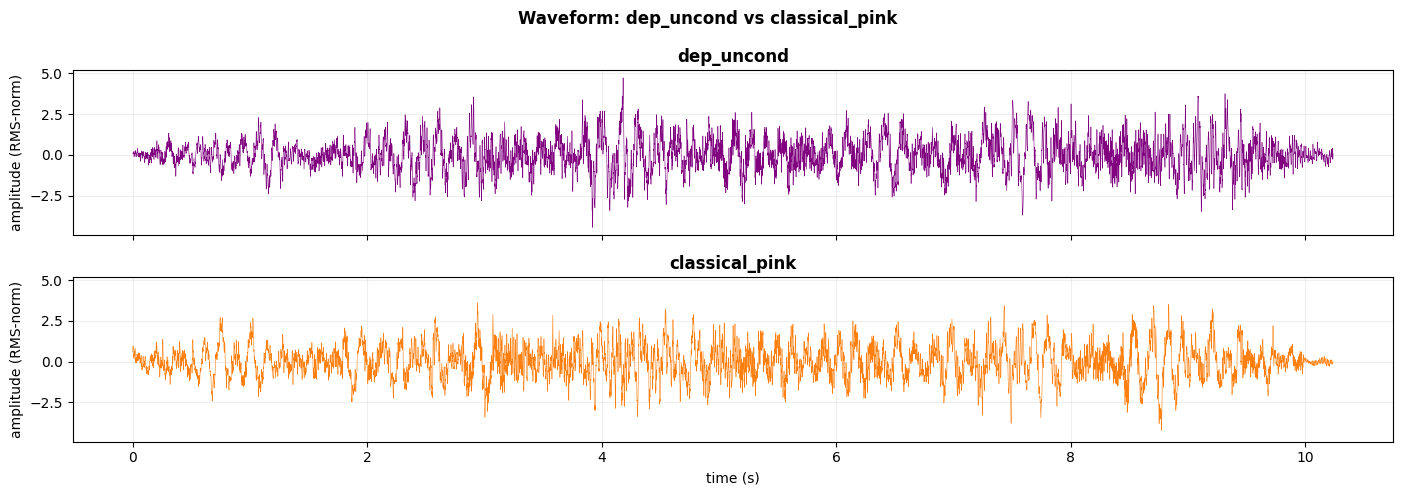

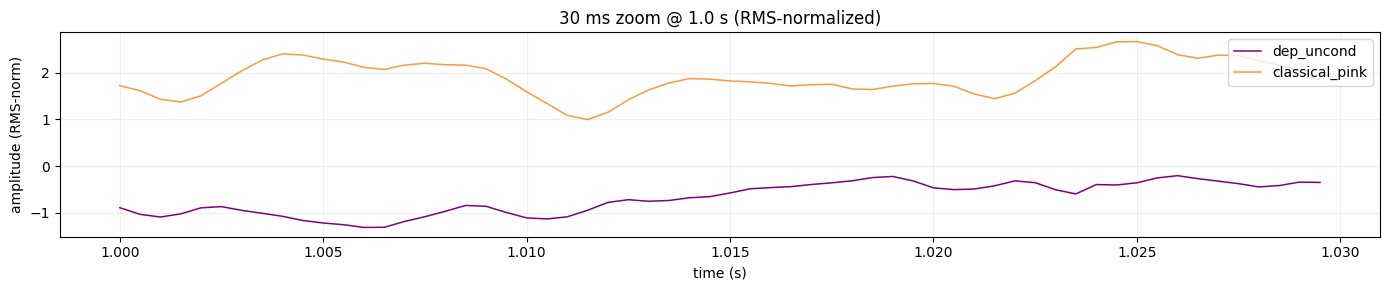

RMS (pre-norm):  dep_uncond=0.2517   classical_pink=0.2325   corr=-0.009


In [17]:
# ── Waveform comparison: dep_uncond ("undep") vs classical_pink ──────────────
u  = np.asarray(results['dep_uncond'])
pk = np.asarray(results['classical_pink'])
m  = min(len(u), len(pk)); u = u[:m]; pk = pk[:m]
t  = np.arange(m) / fs
# normalize each to unit RMS so the SHAPES are comparable (levels differ; true RMS printed below)
_ru, _rpk = np.sqrt(np.mean(u**2)), np.sqrt(np.mean(pk**2))
u  = u  / (_ru  + 1e-12)
pk = pk / (_rpk + 1e-12)

# full waveforms (stacked so envelopes are comparable)
fig, ax = plt.subplots(2, 1, figsize=(14, 5), sharex=True, sharey=True)
ax[0].plot(t, u,  lw=0.4, color='purple'); ax[0].set_title('dep_uncond', fontweight='bold')
ax[1].plot(t, pk, lw=0.4, color='C1');     ax[1].set_title('classical_pink', fontweight='bold')
for a in ax: a.set_ylabel('amplitude (RMS-norm)'); a.grid(alpha=0.2)
ax[1].set_xlabel('time (s)')
plt.suptitle('Waveform: dep_uncond vs classical_pink', fontweight='bold')
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, 'wave_uncond_vs_pink.png'), dpi=140, bbox_inches='tight'); plt.show()

# 30 ms zoom (overlaid) to compare the actual wave shape
i0, win = int(1.0*fs), int(0.03*fs)
fig, ax = plt.subplots(figsize=(14, 3))
ax.plot(t[i0:i0+win], u[i0:i0+win],  lw=1.1, color='purple', label='dep_uncond')
ax.plot(t[i0:i0+win], pk[i0:i0+win], lw=1.1, color='C1', alpha=0.8, label='classical_pink')
ax.set_xlabel('time (s)'); ax.set_ylabel('amplitude (RMS-norm)'); ax.set_title('30 ms zoom @ 1.0 s (RMS-normalized)')
ax.legend(loc='upper right'); ax.grid(alpha=0.2)
plt.tight_layout(); plt.show()

print(f'RMS (pre-norm):  dep_uncond={_ru:.4f}   classical_pink={_rpk:.4f}   '
      f'corr={np.corrcoef(u, pk)[0,1]:.3f}')


## 14. Re-render latest run with amp OFF (no recompute)

In [18]:
# Re-render the LAST transform output with the quantum AMPLITUDE OFF: original
# magnitude + quantum (delayed-choice) phase, through the SAME render route as §4.
# (B18 fix: the old cell passed uqa=True with the quantum magnitudes — i.e. amp ON —
# and rendered through the SMS engine even in STFT mode, so the *_ampOFF.wav files
# were mislabeled AND not comparable to the §4 outputs.)
ampoff = {}
for v in ['uncond', 'cond0', 'cond1']:
    if RESIDUAL_INPUT == 'sms':
        y, _ = synth_full_stft(out_mag_n[v] * scale_per_bin[np.newaxis, :], out_phase[v],
                               uqa=False, uqp=USE_QUANTUM_PHASE, usp=CONDITION_HARMONIC_PHASE)
    else:   # STFT route, matching §4: original |X|, quantum phase (time-aligned since B16)
        y = _istft_declick(in_mag, out_phase[v])
    ampoff['dep_' + v] = y
    pth = os.path.join(OUT_DIR, f'dep_{v}_ampOFF.wav')
    soundfile.write(pth, y.astype(np.float32), fs)
    print(f'dep_{v:7s} (amp OFF)  rms={np.sqrt(np.mean(y**2)):.4f}  -> {pth}')
    display(Audio(y, rate=fs))


  [declick] interpolated 45 samples (0.22%) at 1 intra-frame offsets
dep_uncond  (amp OFF)  rms=0.2322  -> output/dependent_trajectory/dep_uncond_ampOFF.wav


  [declick] interpolated 45 samples (0.22%) at 1 intra-frame offsets
dep_cond0   (amp OFF)  rms=0.2322  -> output/dependent_trajectory/dep_cond0_ampOFF.wav


  [declick] interpolated 45 samples (0.22%) at 1 intra-frame offsets
dep_cond1   (amp OFF)  rms=0.2322  -> output/dependent_trajectory/dep_cond1_ampOFF.wav


## 15. ⚡ Optimized-unitary re-run of §4 (fast=True) vs standard (fast=False)

Runs the **same simulation as §4** (`dependent_colour_transform_per_bin`, route-1
conditional) twice — standard (`fast=False`) and optimized (`fast=True`) — for an
**actual measured** head-to-head time, an **f–t (spectral) equivalence** check, and
audio output (+ TS1 colored stretch, TS2 phase-vocoder) of the optimized run.

*Requires cells above to have run (uses `in_mag`, `DELAY`, `synth_full_stft`, …).*
Note: `fast` only beats standard for **delay ≳ 8–9**; at delay 5–6 it is at/ below
the crossover (equal or slower) but still bit-identical — the point here is
equivalence + the real timing number at your chosen `DELAY`.

In [ ]:
import time as _time, librosa
from quantum_audio_master import time_stretch

def _run_dep(fast):
    t0 = _time.perf_counter()
    # B19 fix: was gamma_x=GAMMA (removed dead knob), amp_gain=AMP_GAIN (None -> TypeError),
    # base_seed=BASE_SEED (None -> TypeError), and omitted amp_mode/soft_gain/omega_s_res —
    # so it crashed AND would not have replicated §4. Now mirrors the §4 call exactly.
    om, oph, spb, _ = dependent_colour_transform_per_bin(
        in_mag, in_phase, freq_bins, np.arange(num_bins), DELAY, PHASE,
        n_traj=N_TRAJ, base_seed=_seed, gamma_x=GAMMA_X, gamma_z=GAMMA_Z,
        interaction=INTERACTION, freq_scale=FREQ_SCALE, measurement_basis=BASIS,
        amp_gain=AMP_GAIN_EFF, amp_mode=AMP_MODE, amp_pow=AMP_POW, soft_gain=SOFT_GAIN,
        omega_s_res=OMEGA_S_RES, fs=fs, verbose=False, fast=fast)
    return om, oph, spb, (_time.perf_counter() - t0)

print(f'delay={DELAY}  n_traj={N_TRAJ}  bins={num_bins}  frames={in_mag.shape[0]}')
print('running STANDARD  (fast=False) ...'); om_s, oph_s, spb_s, t_s = _run_dep(False); print(f'  standard : {t_s:.1f}s')
print('running OPTIMIZED (fast=True ) ...'); om_f, oph_f, spb_f, t_f = _run_dep(True);  print(f'  optimized: {t_f:.1f}s')

mdiff = max(np.max(np.abs(om_s[v]  - om_f[v]))  for v in ['uncond','cond0','cond1'])
pdiff = max(np.max(np.abs(oph_s[v] - oph_f[v])) for v in ['uncond','cond0','cond1'])
print(f'\n>>> delay={DELAY}:  standard {t_s:.1f}s   vs   optimized {t_f:.1f}s   speedup = {t_s/t_f:.2f}x')
print(f'    max |dmag|={mdiff:.2e}   max |dphase|={pdiff:.2e}   -> '
      + ('IDENTICAL (machine precision)' if max(mdiff, pdiff) < 1e-9 else 'DIFFERS!'))

# --- render audio for BOTH, identical synth path to section 4 ---
def _render(om, oph, spb):
    out = {}
    for v in ['uncond','cond0','cond1']:
        om_real = om[v] * spb[np.newaxis, :]
        if RESIDUAL_INPUT == 'sms':
            out['dep_'+v], _ = synth_full_stft(om_real, oph[v], uqa=USE_QUANTUM_AMP,
                                               uqp=USE_QUANTUM_PHASE, usp=CONDITION_HARMONIC_PHASE)
        else:
            _mag   = om_real if USE_QUANTUM_AMP else in_mag
            _phase = oph[v]  if USE_QUANTUM_PHASE else in_phase
            out['dep_'+v] = _istft_declick(_mag, _phase)
    return out
aud_s = _render(om_s, oph_s, spb_s)
aud_f = _render(om_f, oph_f, spb_f)

# --- f-t comparison: spectrogram(standard) | spectrogram(optimized) | |d f-t magnitude| ---
fig, ax = plt.subplots(1, 3, figsize=(18, 4))
for a, (lab, sig) in zip(ax, [('standard', aud_s['dep_uncond']), ('optimized', aud_f['dep_uncond'])]):
    f, t, S = scipy_spectrogram(np.nan_to_num(np.asarray(sig, float)), fs=fs, nperseg=1024, noverlap=768)
    SdB = 10*np.log10(S + 1e-12); vmax = SdB.max()
    a.pcolormesh(t, f, SdB, vmin=vmax-80, vmax=vmax, shading='gouraud', cmap='inferno')
    a.set_ylim(0, 6000); a.set_title(f'dep_uncond f-t — {lab}', fontweight='bold')
    a.set_xlabel('s'); a.set_ylabel('Hz')
d_ft = np.abs(om_s['uncond'] - om_f['uncond'])
im = ax[2].imshow(d_ft.T, aspect='auto', origin='lower', cmap='magma',
                  extent=[0, om_s['uncond'].shape[0], freq_bins[0], freq_bins[-1]])
ax[2].set_title(f'|d f-t magnitude| (uncond)  max={mdiff:.1e}', fontweight='bold')
ax[2].set_xlabel('frame'); ax[2].set_ylabel('Hz'); plt.colorbar(im, ax=ax[2])
plt.suptitle(f'f-t: OPTIMIZED vs STANDARD  (delay {DELAY})'); plt.tight_layout(); plt.show()

# --- audio: dep_uncond standard vs optimized ---
print('\n--- dep_uncond audio ---')
for lab, sig in [('STANDARD  (fast=False)', aud_s['dep_uncond']), ('OPTIMIZED (fast=True )', aud_f['dep_uncond'])]:
    print(lab); display(Audio(np.nan_to_num(np.asarray(sig, float)), rate=fs))

# --- TS1 (colored resample) + TS2 (phase-vocoder) of the OPTIMIZED dep_uncond, exported ---
TS1_FACTOR, TS2_FACTOR = 2.0, 2.0
opt = np.nan_to_num(np.asarray(aud_f['dep_uncond'], dtype=float))
ts1_opt = time_stretch(opt, TS1_FACTOR)
ts2_opt = librosa.effects.time_stretch(opt.astype(np.float32), rate=1.0/TS2_FACTOR)
for tag, sig in [(f'd{DELAY}', opt), (f'd{DELAY}_TS1x{TS1_FACTOR}', ts1_opt), (f'd{DELAY}_TS2x{TS2_FACTOR}', ts2_opt)]:
    soundfile.write(os.path.join(OUT_DIR, f'OPT_dep_uncond_{tag}.wav'), np.asarray(sig, np.float32), fs)
print(f'\n--- OPTIMIZED dep_uncond  +  TS1 colored x{TS1_FACTOR}  +  TS2 pvoc x{TS2_FACTOR} ---')
for lab, sig in [('optimized dep_uncond', opt), (f'TS1 x{TS1_FACTOR} (colored)', ts1_opt), (f'TS2 x{TS2_FACTOR} (pvoc)', ts2_opt)]:
    print(lab); display(Audio(sig, rate=fs))
print(f'saved 3 wavs -> {OUT_DIR}/OPT_dep_uncond_d{DELAY}*.wav')


delay=6  n_traj=1  bins=513  frames=40
running STANDARD  (fast=False) ...
